In [98]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import sqlite3
import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, NNConv

In [99]:
# ============================================================
# 2. PROJECT PATH AND DATABASE CONNECTION
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

db_path = project_root / "data" / "thesis_database.db"

print("Project root:", project_root)
print("Database path:", db_path)
print("Database exists:", db_path.exists())

conn = sqlite3.connect(db_path)

print("Connected to database")

Project root: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool
Database path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db
Database exists: True
Connected to database


In [100]:
# ============================================================
# 3B. IMPORT EVENT DETECTORS
# ============================================================

events_path = event_files[0]
events_folder = events_path.parent

if str(events_folder) not in sys.path:
    sys.path.append(str(events_folder))

import events
importlib.reload(events)

from events import SimpleEventDetector, CombinedEventDetector

print("Event detectors imported correctly")
print("Using events.py from:", events_path)

Event detectors imported correctly
Using events.py from: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\src\events.py


In [101]:
# ============================================================
# 4. LOAD SELECTED BIDDING ZONES
# ============================================================

zones_df = pd.read_sql_query(
    """
    SELECT *
    FROM BiddingZones
    ORDER BY zone_id;
    """,
    conn
)

selected_zone_codes = [
    "NO1", "NO2", "NO3", "NO4", "NO5",
    "SE1", "SE2", "SE3", "SE4",
    "DK1", "DK2",
    "FI",
]

selected_zones = (
    zones_df[zones_df["zone_code"].isin(selected_zone_codes)]
    .copy()
    .sort_values("zone_code")
    .reset_index(drop=True)
)

selected_zone_ids = selected_zones["zone_id"].tolist()
zone_ids_sql = ",".join(str(z) for z in selected_zone_ids)

zone_id_to_node_idx = {
    int(zone_id): idx
    for idx, zone_id in enumerate(selected_zones["zone_id"].values)
}

node_idx_to_zone_code = {
    idx: row["zone_code"]
    for idx, row in selected_zones.iterrows()
}

zone_id_to_code = dict(zip(zones_df["zone_id"], zones_df["zone_code"]))

display(selected_zones)

print("zone_id_to_node_idx:")
print(zone_id_to_node_idx)

print("node_idx_to_zone_code:")
print(node_idx_to_zone_code)

,zone_id,zone_code,country,region_id
0,9,DK1,Denmark,3
1,10,DK2,Denmark,3
2,11,FI,Finland,3
3,12,NO1,Norway,3
4,13,NO2,Norway,3
5,14,NO3,Norway,3
6,15,NO4,Norway,3
7,16,NO5,Norway,3
8,17,SE1,Sweden,3
9,18,SE2,Sweden,3


zone_id_to_node_idx:
{9: 0, 10: 1, 11: 2, 12: 3, 13: 4, 14: 5, 15: 6, 16: 7, 17: 8, 18: 9, 19: 10, 20: 11}
node_idx_to_zone_code:
{0: 'DK1', 1: 'DK2', 2: 'FI', 3: 'NO1', 4: 'NO2', 5: 'NO3', 6: 'NO4', 7: 'NO5', 8: 'SE1', 9: 'SE2', 10: 'SE3', 11: 'SE4'}


In [102]:
# ============================================================
# 5. LOAD BASE NODE DATA
# ============================================================

node_df = pd.read_sql_query(
    f"""
    SELECT
        p.zone_id,
        p.delivery_day,
        p.hour,
        p.price_value,
        v.buy_volume_value,
        v.sell_volume_value
    FROM Prices p
    LEFT JOIN Volumes v
        ON p.zone_id = v.zone_id
       AND p.delivery_day = v.delivery_day
       AND p.hour = v.hour
    WHERE p.zone_id IN ({zone_ids_sql})
    ORDER BY p.delivery_day, p.hour, p.zone_id;
    """,
    conn
)

node_df["datetime"] = (
    pd.to_datetime(node_df["delivery_day"])
    + pd.to_timedelta(node_df["hour"], unit="h")
)

node_df = node_df.sort_values(["zone_id", "datetime"]).copy()

print("Node rows:", len(node_df))
print("Datetime range:", node_df["datetime"].min(), "->", node_df["datetime"].max())

display(node_df.head(10))
display(node_df.tail(10))

Node rows: 604836
Datetime range: 2020-01-01 00:00:00 -> 2025-09-30 23:00:00


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
0,9,2020-01-01,0,33.42,1497.1,2239.7,2020-01-01 00:00:00
12,9,2020-01-01,1,31.77,1529.5,2393.3,2020-01-01 01:00:00
24,9,2020-01-01,2,31.57,1526.9,2615.4,2020-01-01 02:00:00
36,9,2020-01-01,3,31.28,1465.8,2794.3,2020-01-01 03:00:00
48,9,2020-01-01,4,30.85,1466.9,2870.0,2020-01-01 04:00:00
60,9,2020-01-01,5,30.14,1462.7,2939.1,2020-01-01 05:00:00
72,9,2020-01-01,6,30.17,1504.9,3022.4,2020-01-01 06:00:00
84,9,2020-01-01,7,30.00,1538.4,3045.2,2020-01-01 07:00:00
96,9,2020-01-01,8,30.63,1584.8,3131.2,2020-01-01 08:00:00
108,9,2020-01-01,9,30.59,1629.1,3372.8,2020-01-01 09:00:00


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
604727,20,2025-09-30,14,87.95,NaN,NaN,2025-09-30 14:00:00
604739,20,2025-09-30,15,94.85,NaN,NaN,2025-09-30 15:00:00
604751,20,2025-09-30,16,105.58,NaN,NaN,2025-09-30 16:00:00
604763,20,2025-09-30,17,137.83,NaN,NaN,2025-09-30 17:00:00
604775,20,2025-09-30,18,279.41,NaN,NaN,2025-09-30 18:00:00
604787,20,2025-09-30,19,231.30,NaN,NaN,2025-09-30 19:00:00
604799,20,2025-09-30,20,118.33,NaN,NaN,2025-09-30 20:00:00
604811,20,2025-09-30,21,102.48,NaN,NaN,2025-09-30 21:00:00
604823,20,2025-09-30,22,92.35,NaN,NaN,2025-09-30 22:00:00
604835,20,2025-09-30,23,73.62,NaN,NaN,2025-09-30 23:00:00


In [103]:
# ============================================================
# 5B. FILTER NODE DATA TO 2020
# ============================================================

start_date = pd.Timestamp("2020-01-01 00:00:00")
end_date = pd.Timestamp("2020-12-31 23:00:00")

node_df = node_df[
    (node_df["datetime"] >= start_date) &
    (node_df["datetime"] <= end_date)
].copy()

node_df = node_df.sort_values(["zone_id", "datetime"]).copy()

print("Filtered node rows:", len(node_df))
print("Datetime range:", node_df["datetime"].min(), "->", node_df["datetime"].max())

print("Missing values:")
display(node_df[["price_value", "buy_volume_value", "sell_volume_value"]].isna().sum())

display(node_df.head(10))
display(node_df.tail(10))

Filtered node rows: 105432
Datetime range: 2020-01-01 00:00:00 -> 2020-12-31 23:00:00
Missing values:


price_value          0
buy_volume_value     0
sell_volume_value    0
dtype: int64

,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
0,9,2020-01-01,0,33.42,1497.1,2239.7,2020-01-01 00:00:00
12,9,2020-01-01,1,31.77,1529.5,2393.3,2020-01-01 01:00:00
24,9,2020-01-01,2,31.57,1526.9,2615.4,2020-01-01 02:00:00
36,9,2020-01-01,3,31.28,1465.8,2794.3,2020-01-01 03:00:00
48,9,2020-01-01,4,30.85,1466.9,2870.0,2020-01-01 04:00:00
60,9,2020-01-01,5,30.14,1462.7,2939.1,2020-01-01 05:00:00
72,9,2020-01-01,6,30.17,1504.9,3022.4,2020-01-01 06:00:00
84,9,2020-01-01,7,30.00,1538.4,3045.2,2020-01-01 07:00:00
96,9,2020-01-01,8,30.63,1584.8,3131.2,2020-01-01 08:00:00
108,9,2020-01-01,9,30.59,1629.1,3372.8,2020-01-01 09:00:00


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
105323,20,2020-12-31,14,53.08,2599.1,576.4,2020-12-31 14:00:00
105335,20,2020-12-31,15,56.54,2706.5,580.7,2020-12-31 15:00:00
105347,20,2020-12-31,16,59.20,2852.4,582.8,2020-12-31 16:00:00
105359,20,2020-12-31,17,61.34,2860.3,588.7,2020-12-31 17:00:00
105371,20,2020-12-31,18,61.08,2743.6,589.7,2020-12-31 18:00:00
105383,20,2020-12-31,19,58.04,2629.3,577.3,2020-12-31 19:00:00
105395,20,2020-12-31,20,54.45,2527.7,538.0,2020-12-31 20:00:00
105407,20,2020-12-31,21,51.18,2452.0,464.6,2020-12-31 21:00:00
105419,20,2020-12-31,22,45.84,2397.3,450.7,2020-12-31 22:00:00
105431,20,2020-12-31,23,24.07,2335.7,392.8,2020-12-31 23:00:00


In [104]:
# ============================================================
# 6. DETECT NODE EVENTS
# ============================================================

simple_detector = SimpleEventDetector()
combined_detector = CombinedEventDetector()

node_df_events = node_df.copy()

# Price events
node_df_events = simple_detector.detect_price_events(node_df_events)

# Volume events
node_df_events = simple_detector.detect_volume_events(node_df_events)

# Combined price + volume events
node_df_events = combined_detector.detect_combined_events(node_df_events)

print("Node dataframe with events:")
display(node_df_events.head(10))

print("Number of columns:", len(node_df_events.columns))

print("Event columns preview:")
event_cols_preview = [
    "low_price",
    "high_price",
    "price_spike",
    "rapid_price_change",
    "high_demand",
    "low_demand",
    "high_generation",
    "low_generation",
    "generation_surplus",
    "demand_pressure",
    "scarcity_price_event",
    "oversupply_price_event",
]

display(node_df_events[event_cols_preview].head(10))

print("Event counts:")
display(node_df_events[event_cols_preview].sum().sort_values(ascending=False))

Node dataframe with events:


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime,price_delta,abs_price_delta,rolling_volatility_24h,...,sell_pressure_low_price,system_price_max,system_price_min,system_price_spread,price_separation,extreme_price_separation,system_price_median,price_deviation_from_system,zone_price_outlier,has_combined_event
0,9,2020-01-01,0,33.42,1497.1,2239.7,2020-01-01 00:00:00,NaN,NaN,NaN,...,False,33.42,28.78,4.64,False,False,28.78,4.64,False,False
12,9,2020-01-01,1,31.77,1529.5,2393.3,2020-01-01 01:00:00,-1.65,1.65,NaN,...,False,31.77,28.45,3.32,False,False,28.45,3.32,False,False
24,9,2020-01-01,2,31.57,1526.9,2615.4,2020-01-01 02:00:00,-0.20,0.20,NaN,...,False,31.57,27.90,3.67,False,False,27.90,3.67,False,False
36,9,2020-01-01,3,31.28,1465.8,2794.3,2020-01-01 03:00:00,-0.29,0.29,NaN,...,False,31.28,27.52,3.76,False,False,27.52,3.76,False,False
48,9,2020-01-01,4,30.85,1466.9,2870.0,2020-01-01 04:00:00,-0.43,0.43,NaN,...,False,30.85,27.54,3.31,False,False,27.54,3.31,False,False
60,9,2020-01-01,5,30.14,1462.7,2939.1,2020-01-01 05:00:00,-0.71,0.71,1.103136,...,False,30.27,26.55,3.72,False,False,26.55,3.59,False,False
72,9,2020-01-01,6,30.17,1504.9,3022.4,2020-01-01 06:00:00,0.03,0.03,1.126364,...,False,30.17,25.83,4.34,False,False,25.83,4.34,False,False
84,9,2020-01-01,7,30.00,1538.4,3045.2,2020-01-01 07:00:00,-0.17,0.17,1.141653,...,False,30.14,25.07,5.07,False,False,25.07,4.93,False,False
96,9,2020-01-01,8,30.63,1584.8,3131.2,2020-01-01 08:00:00,0.63,0.63,1.081894,...,False,30.63,25.65,4.98,False,False,25.65,4.98,False,False
108,9,2020-01-01,9,30.59,1629.1,3372.8,2020-01-01 09:00:00,-0.04,0.04,1.032309,...,False,30.59,26.15,4.44,False,False,26.15,4.44,False,False


Number of columns: 50
Event columns preview:


,low_price,high_price,price_spike,rapid_price_change,high_demand,low_demand,high_generation,low_generation,generation_surplus,demand_pressure,scarcity_price_event,oversupply_price_event
0,False,False,False,False,False,False,False,False,False,False,False,False
12,False,False,False,False,False,False,False,False,False,False,False,False
24,False,False,False,False,False,False,False,False,False,False,False,False
36,False,False,False,False,False,False,False,False,False,False,False,False
48,False,False,False,False,False,False,False,False,False,False,False,False
60,False,False,False,False,False,True,False,False,False,False,False,False
72,False,False,False,False,False,False,False,False,False,False,False,False
84,False,False,False,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False,False,False,False
108,False,False,False,False,False,False,False,False,False,False,False,False


Event counts:


high_generation           10548
high_demand               10545
low_generation            10543
low_demand                10543
high_price                10535
low_price                 10495
price_spike                5278
rapid_price_change         5265
generation_surplus           93
demand_pressure              69
oversupply_price_event       32
scarcity_price_event         18
dtype: int64

In [105]:
# ============================================================
# 7. ADD TARGET AND LAG FEATURES
# ============================================================

node_df_events = node_df_events.sort_values(["zone_id", "datetime"]).copy()

# Target t+1
node_df_events["target_price_t_plus_1"] = (
    node_df_events.groupby("zone_id")["price_value"]
    .shift(-1)
)

# Price lags
lags = [1, 2, 24]

for lag in lags:
    node_df_events[f"price_lag_{lag}"] = (
        node_df_events.groupby("zone_id")["price_value"]
        .shift(lag)
    )

print("Missing values in lags and target:")
display(
    node_df_events[
        ["target_price_t_plus_1", "price_lag_1", "price_lag_2", "price_lag_24"]
    ].isna().sum()
)

display(node_df_events.head(30))

Missing values in lags and target:


target_price_t_plus_1     12
price_lag_1               12
price_lag_2               24
price_lag_24             288
dtype: int64

,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime,price_delta,abs_price_delta,rolling_volatility_24h,...,price_separation,extreme_price_separation,system_price_median,price_deviation_from_system,zone_price_outlier,has_combined_event,target_price_t_plus_1,price_lag_1,price_lag_2,price_lag_24
0,9,2020-01-01,0,33.42,1497.1,2239.7,2020-01-01 00:00:00,NaN,NaN,NaN,...,False,False,28.78,4.64,False,False,31.77,NaN,NaN,NaN
12,9,2020-01-01,1,31.77,1529.5,2393.3,2020-01-01 01:00:00,-1.65,1.65,NaN,...,False,False,28.45,3.32,False,False,31.57,33.42,NaN,NaN
24,9,2020-01-01,2,31.57,1526.9,2615.4,2020-01-01 02:00:00,-0.20,0.20,NaN,...,False,False,27.90,3.67,False,False,31.28,31.77,33.42,NaN
36,9,2020-01-01,3,31.28,1465.8,2794.3,2020-01-01 03:00:00,-0.29,0.29,NaN,...,False,False,27.52,3.76,False,False,30.85,31.57,31.77,NaN
48,9,2020-01-01,4,30.85,1466.9,2870.0,2020-01-01 04:00:00,-0.43,0.43,NaN,...,False,False,27.54,3.31,False,False,30.14,31.28,31.57,NaN
60,9,2020-01-01,5,30.14,1462.7,2939.1,2020-01-01 05:00:00,-0.71,0.71,1.103136,...,False,False,26.55,3.59,False,False,30.17,30.85,31.28,NaN
72,9,2020-01-01,6,30.17,1504.9,3022.4,2020-01-01 06:00:00,0.03,0.03,1.126364,...,False,False,25.83,4.34,False,False,30.00,30.14,30.85,NaN
84,9,2020-01-01,7,30.00,1538.4,3045.2,2020-01-01 07:00:00,-0.17,0.17,1.141653,...,False,False,25.07,4.93,False,False,30.63,30.17,30.14,NaN
96,9,2020-01-01,8,30.63,1584.8,3131.2,2020-01-01 08:00:00,0.63,0.63,1.081894,...,False,False,25.65,4.98,False,False,30.59,30.00,30.17,NaN
108,9,2020-01-01,9,30.59,1629.1,3372.8,2020-01-01 09:00:00,-0.04,0.04,1.032309,...,False,False,26.15,4.44,False,False,30.27,30.63,30.00,NaN


In [106]:
# ============================================================
# 8. DEFINE NODE FEATURE COLUMNS WITH EVENTS
# ============================================================

base_node_features = [
    "price_value",
    "buy_volume_value",
    "sell_volume_value",
    "price_lag_1",
    "price_lag_2",
    "price_lag_24",
]

price_event_features = [
    "low_price",
    "high_price",
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "price_ramp_up",
    "price_ramp_down",
    "high_volatility",
]

volume_event_features = [
    "high_demand",
    "low_demand",
    "high_generation",
    "low_generation",
    "strong_buy_pressure",
    "strong_sell_pressure",
    "buy_volume_spike",
    "sell_volume_spike",
]

combined_event_features = [
    "generation_surplus",
    "demand_pressure",
    "strong_demand_pressure",
    "strong_generation_pressure",
    "demand_driven_price_spike",
    "generation_driven_low_price",
    "scarcity_price_event",
    "oversupply_price_event",
    "buy_pressure_price_spike",
    "sell_pressure_low_price",
    "price_separation",
    "extreme_price_separation",
    "zone_price_outlier",
]

node_event_features = (
    price_event_features
    + volume_event_features
    + combined_event_features
)

node_feature_columns_events = (
    base_node_features
    + node_event_features
)

print("Number of base features:", len(base_node_features))
print("Number of price event features:", len(price_event_features))
print("Number of volume event features:", len(volume_event_features))
print("Number of combined event features:", len(combined_event_features))
print("Number of event features:", len(node_event_features))
print("Total node features:", len(node_feature_columns_events))

print("\nNode feature columns:")
for col in node_feature_columns_events:
    print("-", col)

missing_cols = [
    col for col in node_feature_columns_events
    if col not in node_df_events.columns
]

print("\nMissing columns:", missing_cols)

Number of base features: 6
Number of price event features: 8
Number of volume event features: 8
Number of combined event features: 13
Number of event features: 29
Total node features: 35

Node feature columns:
- price_value
- buy_volume_value
- sell_volume_value
- price_lag_1
- price_lag_2
- price_lag_24
- low_price
- high_price
- price_spike
- extreme_price
- rapid_price_change
- price_ramp_up
- price_ramp_down
- high_volatility
- high_demand
- low_demand
- high_generation
- low_generation
- strong_buy_pressure
- strong_sell_pressure
- buy_volume_spike
- sell_volume_spike
- generation_surplus
- demand_pressure
- strong_demand_pressure
- strong_generation_pressure
- demand_driven_price_spike
- generation_driven_low_price
- scarcity_price_event
- oversupply_price_event
- buy_pressure_price_spike
- sell_pressure_low_price
- price_separation
- extreme_price_separation
- zone_price_outlier

Missing columns: []


In [107]:
# ============================================================
# 9. CONVERT EVENT FEATURES TO FLOAT AND CHECK MISSING VALUES
# ============================================================

node_df_events = node_df_events.copy()

# Convert boolean event columns to float: False -> 0.0, True -> 1.0
for col in node_event_features:
    node_df_events[col] = node_df_events[col].astype(float)

print("Feature preview:")
display(node_df_events[node_feature_columns_events].head(10))

print("Missing values in selected node features:")
missing_features = (
    node_df_events[node_feature_columns_events]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing_features[missing_features > 0])

print("Total missing values in selected node features:")
print(node_df_events[node_feature_columns_events].isna().sum().sum())

print("Data types:")
display(node_df_events[node_feature_columns_events].dtypes.value_counts())

Feature preview:


,price_value,buy_volume_value,sell_volume_value,price_lag_1,price_lag_2,price_lag_24,low_price,high_price,price_spike,extreme_price,...,strong_generation_pressure,demand_driven_price_spike,generation_driven_low_price,scarcity_price_event,oversupply_price_event,buy_pressure_price_spike,sell_pressure_low_price,price_separation,extreme_price_separation,zone_price_outlier
0,33.42,1497.1,2239.7,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,31.77,1529.5,2393.3,33.42,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,31.57,1526.9,2615.4,31.77,33.42,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36,31.28,1465.8,2794.3,31.57,31.77,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48,30.85,1466.9,2870.0,31.28,31.57,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,30.14,1462.7,2939.1,30.85,31.28,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72,30.17,1504.9,3022.4,30.14,30.85,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84,30.00,1538.4,3045.2,30.17,30.14,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,30.63,1584.8,3131.2,30.00,30.17,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108,30.59,1629.1,3372.8,30.63,30.00,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Missing values in selected node features:


price_lag_24    288
price_lag_2      24
price_lag_1      12
dtype: int64

Total missing values in selected node features:
324
Data types:


float64    35
Name: count, dtype: int64

In [108]:
# ============================================================
# 10. LOAD FLOWS AND BUILD EDGE INDEX
# ============================================================

flows_no = pd.read_sql_query(
    f"""
    SELECT *
    FROM Flows
    WHERE from_zone_id IN ({zone_ids_sql})
      AND to_zone_id IN ({zone_ids_sql})
    ORDER BY delivery_day, hour, from_zone_id, to_zone_id;
    """,
    conn
)

flows_no["datetime"] = (
    pd.to_datetime(flows_no["delivery_day"])
    + pd.to_timedelta(flows_no["hour"], unit="h")
)

unique_edges = (
    flows_no[["from_zone_id", "to_zone_id"]]
    .drop_duplicates()
    .sort_values(["from_zone_id", "to_zone_id"])
    .reset_index(drop=True)
)

edge_index_list = []

for _, row in unique_edges.iterrows():
    from_node_idx = zone_id_to_node_idx[int(row["from_zone_id"])]
    to_node_idx = zone_id_to_node_idx[int(row["to_zone_id"])]
    edge_index_list.append([from_node_idx, to_node_idx])

edge_index = np.array(edge_index_list).T

unique_edges_named = unique_edges.copy()
unique_edges_named["from_zone_code"] = unique_edges_named["from_zone_id"].map(zone_id_to_code)
unique_edges_named["to_zone_code"] = unique_edges_named["to_zone_id"].map(zone_id_to_code)

display(unique_edges_named)

print("Flow rows:", len(flows_no))
print("Flow datetime range:", flows_no["datetime"].min(), "->", flows_no["datetime"].max())
print("Number of unique directed edges:", len(unique_edges))
print("edge_index shape:", edge_index.shape)
print(edge_index)

,from_zone_id,to_zone_id,from_zone_code,to_zone_code
0,9,13,DK1,NO2
1,11,15,FI,NO4
2,12,13,NO1,NO2
3,12,14,NO1,NO3
4,12,16,NO1,NO5
5,12,19,NO1,SE3
6,13,9,NO2,DK1
7,13,12,NO2,NO1
8,13,16,NO2,NO5
9,14,12,NO3,NO1


Flow rows: 210792
Flow datetime range: 2020-01-01 00:00:00 -> 2020-12-31 23:00:00
Number of unique directed edges: 24
edge_index shape: (2, 24)
[[ 0  2  3  3  3  3  4  4  4  5  5  5  5  6  6  6  6  7  7  7  8  9  9 10]
 [ 4  6  4  5  7 10  0  3  7  3  6  7  9  2  5  8  9  3  4  5  6  5  6  3]]


In [109]:
# ============================================================
# 11. EDGE FEATURE COLUMNS
# ============================================================

edge_feature_columns = [
    "flow_value",
]

print("Edge feature columns:", edge_feature_columns)

Edge feature columns: ['flow_value']


In [110]:
# ============================================================
# 12. FUNCTION TO BUILD ONE GRAPH WITH NODE EVENTS
# ============================================================

def build_graph_for_datetime_events(datetime_value):
    """
    Builds one graph snapshot for a specific datetime using:
    - node features with events
    - edge_attr with flow_value
    - target price t+1
    """

    # -------------------------
    # Node snapshot
    # -------------------------

    node_snapshot = (
        node_df_events[node_df_events["datetime"] == datetime_value]
        .copy()
        .sort_values("zone_id")
    )

    if len(node_snapshot) != len(selected_zone_ids):
        return None

    x = node_snapshot[node_feature_columns_events].to_numpy(dtype=np.float32)
    y = node_snapshot["target_price_t_plus_1"].to_numpy(dtype=np.float32)

    if np.isnan(x).any() or np.isnan(y).any():
        return None

    # -------------------------
    # Edge snapshot
    # -------------------------

    edge_snapshot = (
        flows_no[flows_no["datetime"] == datetime_value]
        .copy()
    )

    edge_snapshot = unique_edges.merge(
        edge_snapshot,
        on=["from_zone_id", "to_zone_id"],
        how="left"
    )

    edge_attr = edge_snapshot[edge_feature_columns].to_numpy(dtype=np.float32)

    if np.isnan(edge_attr).any():
        return None

    return {
        "datetime": datetime_value,
        "x": x,
        "edge_index": edge_index,
        "edge_attr": edge_attr,
        "y": y,
    }

In [111]:
# ============================================================
# 13. BUILD GRAPH DATASET WITH NODE EVENTS
# ============================================================

node_datetimes = set(node_df_events["datetime"].unique())
flow_datetimes = set(flows_no["datetime"].unique())

common_datetimes = sorted(node_datetimes.intersection(flow_datetimes))

graphs_events = []

for datetime_value in common_datetimes:
    graph = build_graph_for_datetime_events(datetime_value)

    if graph is not None:
        graphs_events.append(graph)

print("Common datetimes:", len(common_datetimes))
print("Graphs created with events:", len(graphs_events))
print("Graphs skipped:", len(common_datetimes) - len(graphs_events))

print("First graph datetime:", graphs_events[0]["datetime"])
print("Last graph datetime:", graphs_events[-1]["datetime"])

print("x shape:", graphs_events[0]["x"].shape)
print("edge_index shape:", graphs_events[0]["edge_index"].shape)
print("edge_attr shape:", graphs_events[0]["edge_attr"].shape)
print("y shape:", graphs_events[0]["y"].shape)

Common datetimes: 8783
Graphs created with events: 8757
Graphs skipped: 26
First graph datetime: 2020-01-02 00:00:00
Last graph datetime: 2020-12-31 22:00:00
x shape: (12, 35)
edge_index shape: (2, 24)
edge_attr shape: (24, 1)
y shape: (12,)


In [112]:
# ============================================================
# 14. CONVERT EVENT GRAPH DATASET TO PYTORCH GEOMETRIC
# ============================================================

pyg_graphs_events = []

for graph in graphs_events:
    data = Data(
        x=torch.tensor(graph["x"], dtype=torch.float),
        edge_index=torch.tensor(graph["edge_index"], dtype=torch.long),
        edge_attr=torch.tensor(graph["edge_attr"], dtype=torch.float),
        y=torch.tensor(graph["y"], dtype=torch.float)
    )
    
    data.datetime = graph["datetime"]
    pyg_graphs_events.append(data)

print("Number of PyG event graphs:", len(pyg_graphs_events))
print("First graph:", pyg_graphs_events[0])
print("Last graph:", pyg_graphs_events[-1])

Number of PyG event graphs: 8757
First graph: Data(x=[12, 35], edge_index=[2, 24], edge_attr=[24, 1], y=[12], datetime=2020-01-02 00:00:00)
Last graph: Data(x=[12, 35], edge_index=[2, 24], edge_attr=[24, 1], y=[12], datetime=2020-12-31 22:00:00)


In [147]:
# ============================================================
# 15. TEMPORAL TRAIN / TEST SPLIT WITH NODE EVENTS
#    Train: Jan-Nov 2020
#    Test: first week of December 2020
# ============================================================

train_end = pd.Timestamp("2020-12-01 00:00:00")
test_start = pd.Timestamp("2020-12-01 00:00:00")
test_end = pd.Timestamp("2020-12-31 00:00:00")  # exclusive

train_graphs_events = [
    graph for graph in pyg_graphs_events
    if graph.datetime < train_end
]

test_graphs_events = [
    graph for graph in pyg_graphs_events
    if (graph.datetime >= test_start) and (graph.datetime < test_end)
]

print("Train graphs with events:", len(train_graphs_events))
print("Test graphs with events:", len(test_graphs_events))

print("Train period:")
print(train_graphs_events[0].datetime, "->", train_graphs_events[-1].datetime)

print("Test period:")
print(test_graphs_events[0].datetime, "->", test_graphs_events[-1].datetime)

Train graphs with events: 8014
Test graphs with events: 720
Train period:
2020-01-02 00:00:00 -> 2020-11-30 23:00:00
Test period:
2020-12-01 00:00:00 -> 2020-12-30 23:00:00


In [148]:
# ============================================================
# 16. NORMALIZE NODE FEATURES, EDGE FEATURES AND TARGET
# ============================================================

train_x_all_events = torch.cat([g.x for g in train_graphs_events], dim=0)
train_edge_attr_all_events = torch.cat([g.edge_attr for g in train_graphs_events], dim=0)
train_y_all_events = torch.cat([g.y for g in train_graphs_events], dim=0)

x_mean_events = train_x_all_events.mean(dim=0)
x_std_events = train_x_all_events.std(dim=0)
x_std_events[x_std_events == 0] = 1.0

edge_mean_events = train_edge_attr_all_events.mean(dim=0)
edge_std_events = train_edge_attr_all_events.std(dim=0)
edge_std_events[edge_std_events == 0] = 1.0

y_mean_events = train_y_all_events.mean()
y_std_events = train_y_all_events.std()

if y_std_events == 0:
    y_std_events = torch.tensor(1.0)

print("x_mean_events shape:", x_mean_events.shape)
print("x_std_events shape:", x_std_events.shape)

print("edge_mean_events:", edge_mean_events)
print("edge_std_events:", edge_std_events)

print("y_mean_events:", y_mean_events)
print("y_std_events:", y_std_events)

x_mean_events shape: torch.Size([35])
x_std_events shape: torch.Size([35])
edge_mean_events: tensor([248.7421])
edge_std_events: tensor([502.0731])
y_mean_events: tensor(16.1230)
y_std_events: tensor(15.7243)


In [149]:
# ============================================================
# 17. CREATE NORMALIZED EVENT GRAPH DATASETS
# ============================================================

def normalize_graph_events(graph, x_mean, x_std, edge_mean, edge_std, y_mean, y_std):
    graph_norm = Data(
        x=(graph.x - x_mean) / x_std,
        edge_index=graph.edge_index,
        edge_attr=(graph.edge_attr - edge_mean) / edge_std,
        y=(graph.y - y_mean) / y_std
    )
    graph_norm.datetime = graph.datetime
    return graph_norm


train_graphs_events_norm = [
    normalize_graph_events(
        g,
        x_mean_events,
        x_std_events,
        edge_mean_events,
        edge_std_events,
        y_mean_events,
        y_std_events
    )
    for g in train_graphs_events
]

test_graphs_events_norm = [
    normalize_graph_events(
        g,
        x_mean_events,
        x_std_events,
        edge_mean_events,
        edge_std_events,
        y_mean_events,
        y_std_events
    )
    for g in test_graphs_events
]

print("Normalized train graphs with events:", len(train_graphs_events_norm))
print("Normalized test graphs with events:", len(test_graphs_events_norm))

print(train_graphs_events_norm[0])

Normalized train graphs with events: 8014
Normalized test graphs with events: 720
Data(x=[12, 35], edge_index=[2, 24], edge_attr=[24, 1], y=[12], datetime=2020-01-02 00:00:00)


In [150]:
# ============================================================
# 18. EVENT EDGE GNN DATALOADERS
# ============================================================

batch_size = 32

train_loader_events_edge = DataLoader(
    train_graphs_events_norm,
    batch_size=batch_size,
    shuffle=False
)

test_loader_events_edge = DataLoader(
    test_graphs_events_norm,
    batch_size=batch_size,
    shuffle=False
)

batch_events_edge = next(iter(train_loader_events_edge))

print("Train batches:", len(train_loader_events_edge))
print("Test batches:", len(test_loader_events_edge))

print(batch_events_edge)
print("Batch x:", batch_events_edge.x.shape)
print("Batch edge_index:", batch_events_edge.edge_index.shape)
print("Batch edge_attr:", batch_events_edge.edge_attr.shape)
print("Batch y:", batch_events_edge.y.shape)

Train batches: 251
Test batches: 23
DataBatch(x=[384, 35], edge_index=[2, 768], edge_attr=[768, 1], y=[384], datetime=[32], batch=[384], ptr=[33])
Batch x: torch.Size([384, 35])
Batch edge_index: torch.Size([2, 768])
Batch edge_attr: torch.Size([768, 1])
Batch y: torch.Size([384])


In [151]:
# ============================================================
# 19. DEFINE EDGE GNN MODEL WITH NODE EVENTS
# ============================================================

class EdgeGNN(nn.Module):
    def __init__(self, node_in_channels, edge_in_channels, hidden_channels):
        super().__init__()

        edge_nn_1 = nn.Sequential(
            nn.Linear(edge_in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, node_in_channels * hidden_channels)
        )

        self.conv1 = NNConv(
            in_channels=node_in_channels,
            out_channels=hidden_channels,
            nn=edge_nn_1,
            aggr="mean"
        )

        edge_nn_2 = nn.Sequential(
            nn.Linear(edge_in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels * hidden_channels)
        )

        self.conv2 = NNConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            nn=edge_nn_2,
            aggr="mean"
        )

        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)

        out = self.lin(x).squeeze(-1)
        return out


node_in_channels_events = train_graphs_events_norm[0].x.shape[1]
edge_in_channels_events = train_graphs_events_norm[0].edge_attr.shape[1]
hidden_channels = 32

edge_model_events = EdgeGNN(
    node_in_channels=node_in_channels_events,
    edge_in_channels=edge_in_channels_events,
    hidden_channels=hidden_channels
)

print(edge_model_events)

EdgeGNN(
  (conv1): NNConv(35, 32, aggr=mean, nn=Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1120, bias=True)
  ))
  (conv2): NNConv(32, 32, aggr=mean, nn=Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1024, bias=True)
  ))
  (lin): Linear(in_features=32, out_features=1, bias=True)
)


In [152]:
# ============================================================
# 20. TEST EDGE GNN WITH NODE EVENTS FORWARD PASS
# ============================================================

batch_events_edge = next(iter(train_loader_events_edge))

with torch.no_grad():
    pred = edge_model_events(
        batch_events_edge.x,
        batch_events_edge.edge_index,
        batch_events_edge.edge_attr
    )

print("Prediction shape:", pred.shape)
print("Target shape:", batch_events_edge.y.shape)

print("First 10 predictions:")
print(pred[:10])

print("First 10 targets:")
print(batch_events_edge.y[:10])

Prediction shape: torch.Size([384])
Target shape: torch.Size([384])
First 10 predictions:
tensor([ 1.9741, -0.2004, -0.1296,  0.2236,  1.3705,  0.8180,  0.6845,  1.5702,
        -0.0576,  0.6844])
First 10 targets:
tensor([ 0.9232,  0.9232, -0.1903,  0.9232,  0.9232, -0.1903, -0.1903,  0.9232,
        -0.1903, -0.1903])


In [153]:
# ============================================================
# 21. TRAINING SETUP FOR EDGE GNN WITH NODE EVENTS
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

edge_model_events = edge_model_events.to(device)

optimizer_edge_events = torch.optim.Adam(
    edge_model_events.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

Device: cpu


In [154]:
# ============================================================
# 22. TRAIN AND EVALUATE FUNCTIONS FOR EDGE GNN WITH EVENTS
# ============================================================

def train_one_epoch_edge(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr
        )

        loss = loss_fn(pred, batch.y)

        loss.backward()
        optimizer.step()

        num_nodes = batch.y.numel()
        total_loss += loss.item() * num_nodes
        total_nodes += num_nodes

    return total_loss / total_nodes


def evaluate_model_edge(model, loader, device, y_mean, y_std):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            pred_norm = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr
            )

            pred = pred_norm.cpu() * y_std + y_mean
            target = batch.y.cpu() * y_std + y_mean

            all_preds.append(pred)
            all_targets.append(target)

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2, y_true, y_pred

In [155]:
# ============================================================
# 23. TRAIN EDGE GNN WITH NODE EVENTS - EARLY STOPPING
# ============================================================

import copy

num_epochs = 100
patience = 10
min_delta = 1e-4

train_losses_edge_events = []
eval_history_edge_events = []

best_rmse_edge_events = float("inf")
best_epoch_edge_events = None
best_model_state_edge_events = None
best_metrics_edge_events = None

epochs_without_improvement = 0

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch_edge(
        model=edge_model_events,
        loader=train_loader_events_edge,
        optimizer=optimizer_edge_events,
        loss_fn=loss_fn,
        device=device
    )

    train_losses_edge_events.append(train_loss)

    test_mae, test_rmse, test_r2, _, _ = evaluate_model_edge(
        model=edge_model_events,
        loader=test_loader_events_edge,
        device=device,
        y_mean=y_mean_events,
        y_std=y_std_events
    )

    eval_history_edge_events.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_r2": test_r2,
    })

    # Check improvement
    if test_rmse < best_rmse_edge_events - min_delta:
        best_rmse_edge_events = test_rmse
        best_epoch_edge_events = epoch
        best_model_state_edge_events = copy.deepcopy(edge_model_events.state_dict())
        best_metrics_edge_events = {
            "MAE": test_mae,
            "RMSE": test_rmse,
            "R2": test_r2,
        }

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Test MAE: {test_mae:.4f} | "
            f"Test RMSE: {test_rmse:.4f} | "
            f"Test R2: {test_r2:.4f} | "
            f"No improvement: {epochs_without_improvement}/{patience}"
        )

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

print("\nBEST EDGE GNN WITH NODE EVENTS")
print("------------------------------")
print(f"Best epoch: {best_epoch_edge_events}")
print(f"Best MAE:  {best_metrics_edge_events['MAE']:.4f}")
print(f"Best RMSE: {best_metrics_edge_events['RMSE']:.4f}")
print(f"Best R2:   {best_metrics_edge_events['R2']:.4f}")

Epoch 001 | Train loss: 0.3418 | Test MAE: 6.5027 | Test RMSE: 10.1622 | Test R2: 0.7477 | No improvement: 0/10
Epoch 005 | Train loss: 0.1139 | Test MAE: 4.7106 | Test RMSE: 8.0543 | Test R2: 0.8415 | No improvement: 0/10
Epoch 010 | Train loss: 0.0997 | Test MAE: 4.4769 | Test RMSE: 8.3641 | Test R2: 0.8291 | No improvement: 1/10
Epoch 015 | Train loss: 0.0935 | Test MAE: 4.5453 | Test RMSE: 8.5657 | Test R2: 0.8207 | No improvement: 6/10

Early stopping triggered at epoch 19

BEST EDGE GNN WITH NODE EVENTS
------------------------------
Best epoch: 9
Best MAE:  4.3060
Best RMSE: 7.8726
Best R2:   0.8486


In [156]:
# ============================================================
# 24. FINAL TEST METRICS - BEST EDGE GNN WITH NODE EVENTS
# ============================================================

edge_model_events.load_state_dict(best_model_state_edge_events)

test_mae_edge_events, test_rmse_edge_events, test_r2_edge_events, y_true_edge_events, y_pred_edge_events = evaluate_model_edge(
    model=edge_model_events,
    loader=test_loader_events_edge,
    device=device,
    y_mean=y_mean_events,
    y_std=y_std_events
)

print("FINAL BEST EDGE GNN WITH NODE EVENTS RESULTS")
print("--------------------------------------------")
print(f"Best epoch: {best_epoch_edge_events}")
print(f"MAE:  {test_mae_edge_events:.4f}")
print(f"RMSE: {test_rmse_edge_events:.4f}")
print(f"R2:   {test_r2_edge_events:.4f}")

FINAL BEST EDGE GNN WITH NODE EVENTS RESULTS
--------------------------------------------
Best epoch: 9
MAE:  4.3060
RMSE: 7.8726
R2:   0.8486


In [157]:
# ============================================================
# 25. CREATE RESULTS DATAFRAME - EDGE GNN WITH NODE EVENTS
# ============================================================

test_datetimes_edge_events = []
test_zone_codes_edge_events = []

for graph in test_graphs_events:
    for node_idx in range(graph.x.shape[0]):
        test_datetimes_edge_events.append(graph.datetime)
        test_zone_codes_edge_events.append(node_idx_to_zone_code[node_idx])

results_edge_events = pd.DataFrame({
    "datetime": test_datetimes_edge_events,
    "zone_code": test_zone_codes_edge_events,
    "y_true": y_true_edge_events,
    "y_pred": y_pred_edge_events,
})

display(results_edge_events.head(15))
display(results_edge_events.tail(15))

,datetime,zone_code,y_true,y_pred
0,2020-12-01 00:00:00,DK1,25.02,25.319477
1,2020-12-01 00:00:00,DK2,25.02,24.616055
2,2020-12-01 00:00:00,FI,12.42,15.367158
3,2020-12-01 00:00:00,NO1,12.42,16.825901
4,2020-12-01 00:00:00,NO2,12.42,12.526593
5,2020-12-01 00:00:00,NO3,10.03,12.018932
6,2020-12-01 00:00:00,NO4,10.03,9.754625
7,2020-12-01 00:00:00,NO5,12.42,11.829536
8,2020-12-01 00:00:00,SE1,12.42,10.887726
9,2020-12-01 00:00:00,SE2,12.42,13.907645


,datetime,zone_code,y_true,y_pred
8625,2020-12-30 22:00:00,SE2,20.940001,22.194555
8626,2020-12-30 22:00:00,SE3,20.940001,27.697496
8627,2020-12-30 22:00:00,SE4,20.940001,21.062420
8628,2020-12-30 23:00:00,DK1,22.490000,21.979639
8629,2020-12-30 23:00:00,DK2,22.490000,19.163980
8630,2020-12-30 23:00:00,FI,22.490000,33.100975
8631,2020-12-30 23:00:00,NO1,22.490000,14.237854
8632,2020-12-30 23:00:00,NO2,22.490000,15.020520
8633,2020-12-30 23:00:00,NO3,19.590000,17.576103
8634,2020-12-30 23:00:00,NO4,17.760000,15.711334


In [158]:
# ============================================================
# 26. METRICS BY ZONE - EDGE GNN WITH NODE EVENTS
# ============================================================

zone_metrics_edge_events = []

for zone_code in sorted(results_edge_events["zone_code"].unique()):
    zone_df = results_edge_events[results_edge_events["zone_code"] == zone_code]

    mae = mean_absolute_error(zone_df["y_true"], zone_df["y_pred"])
    rmse = mean_squared_error(zone_df["y_true"], zone_df["y_pred"]) ** 0.5
    r2 = r2_score(zone_df["y_true"], zone_df["y_pred"])

    zone_metrics_edge_events.append({
        "zone_code": zone_code,
        "MAE_edge_events": mae,
        "RMSE_edge_events": rmse,
        "R2_edge_events": r2,
    })

zone_metrics_edge_events_df = pd.DataFrame(zone_metrics_edge_events)

display(zone_metrics_edge_events_df)

,zone_code,MAE_edge_events,RMSE_edge_events,R2_edge_events
0,DK1,6.490186,9.017441,0.845834
1,DK2,5.963458,11.141159,0.828382
2,FI,7.872679,12.425532,0.832917
3,NO1,3.215883,6.058549,0.562123
4,NO2,3.987389,7.198235,0.381781
5,NO3,2.379650,2.967985,-0.015788
6,NO4,1.086035,1.408321,0.589928
7,NO5,3.332063,5.171912,0.384697
8,SE1,2.294110,3.538125,0.696325
9,SE2,2.083052,3.292608,0.737008


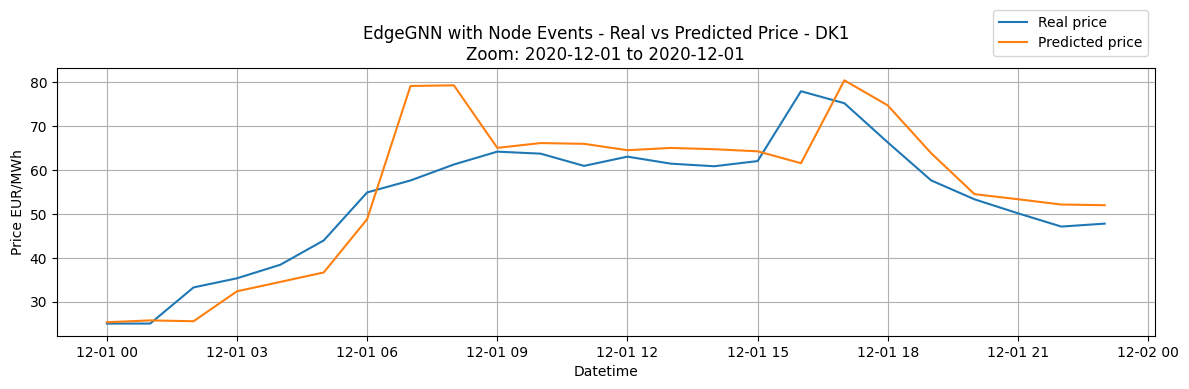

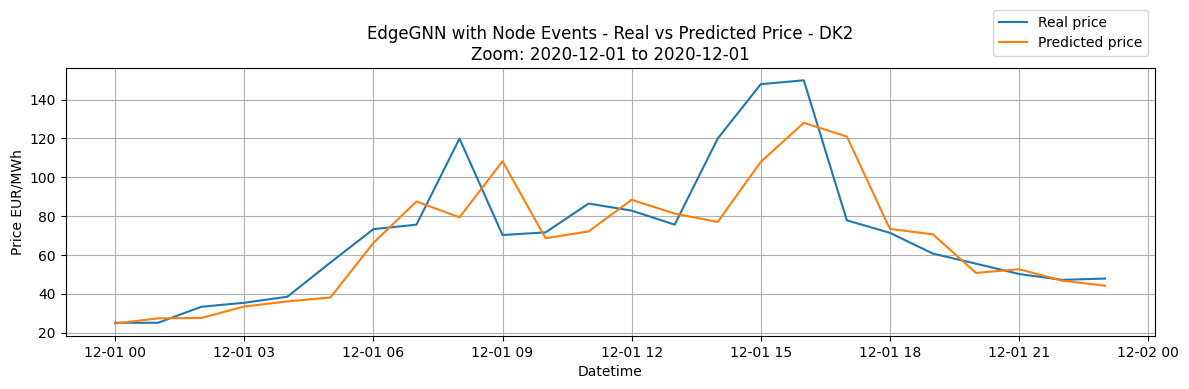

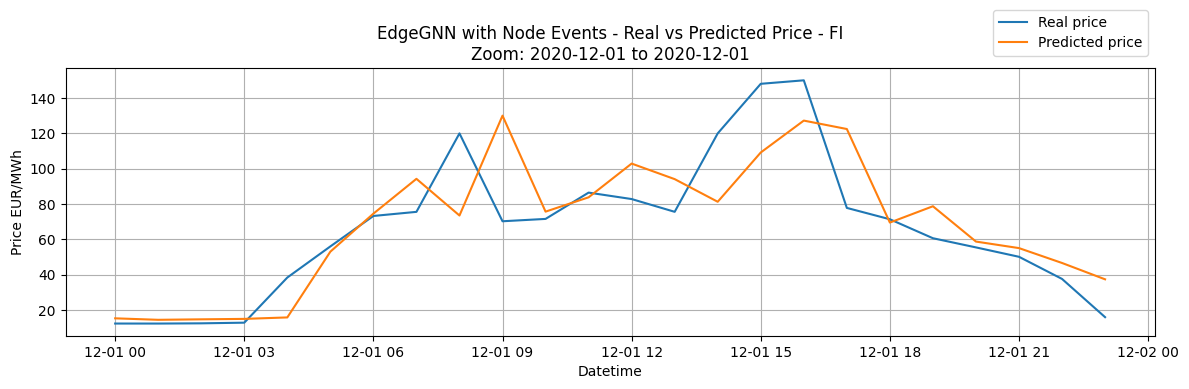

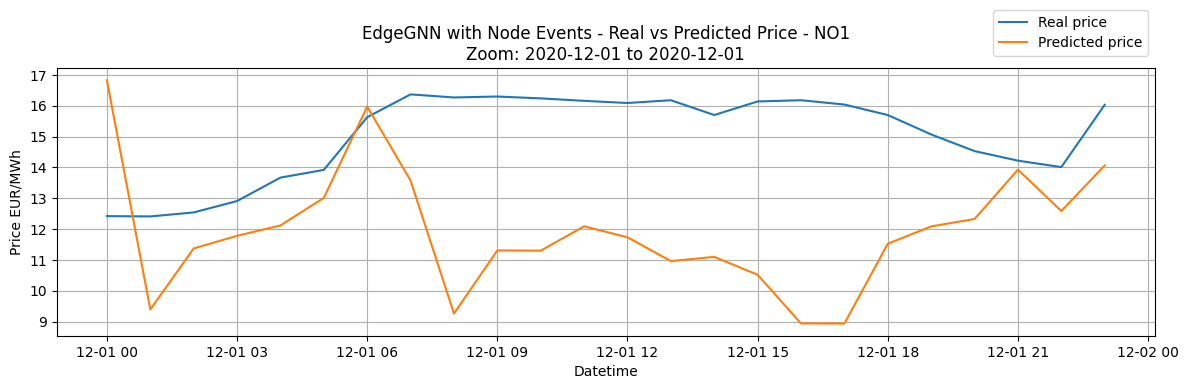

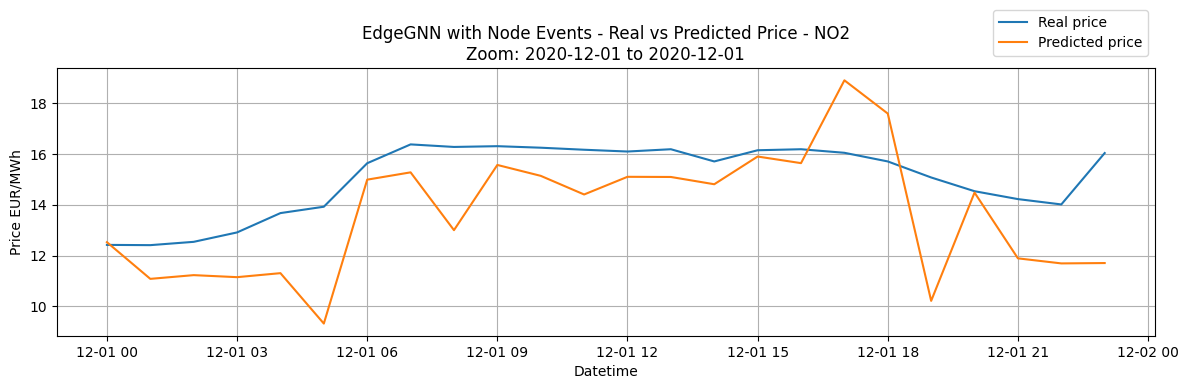

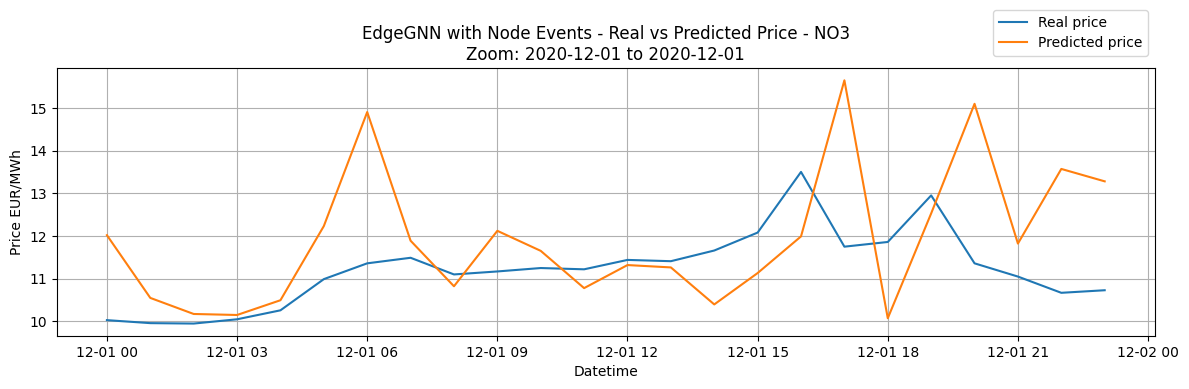

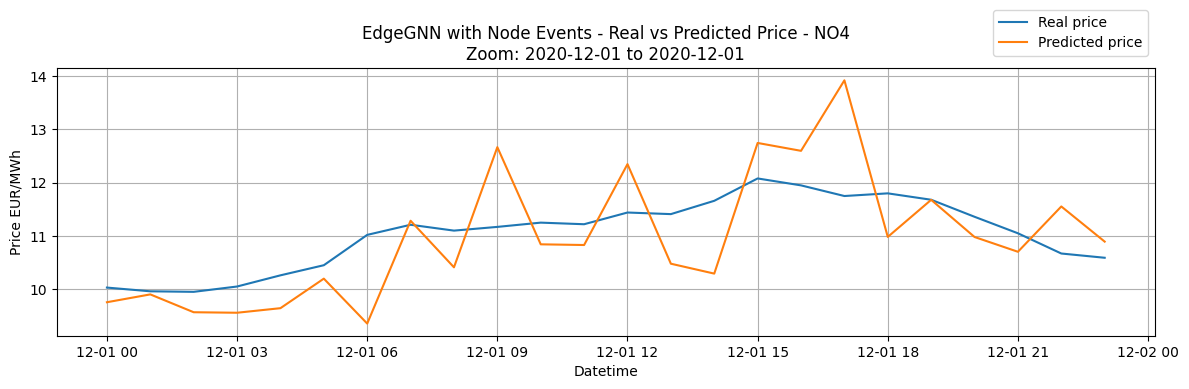

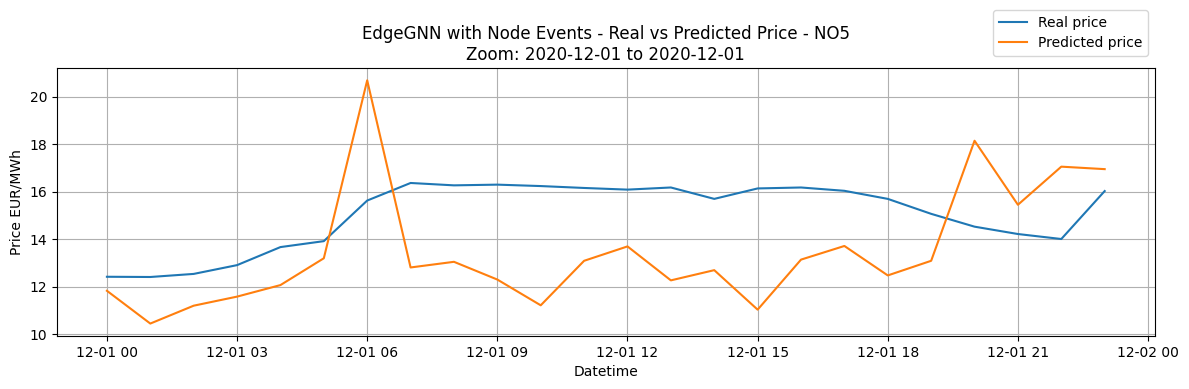

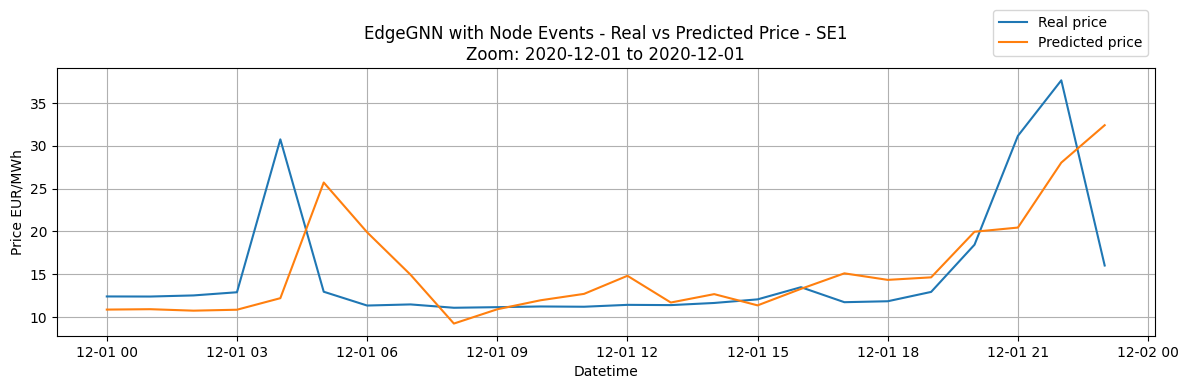

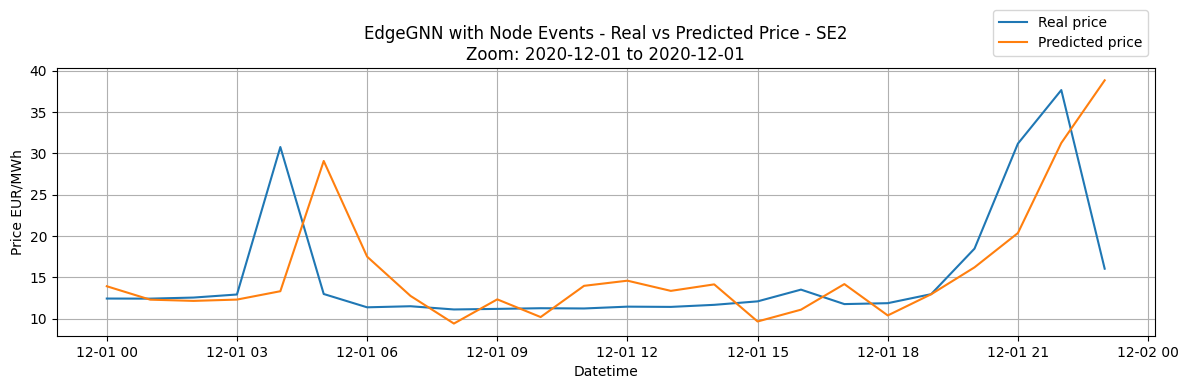

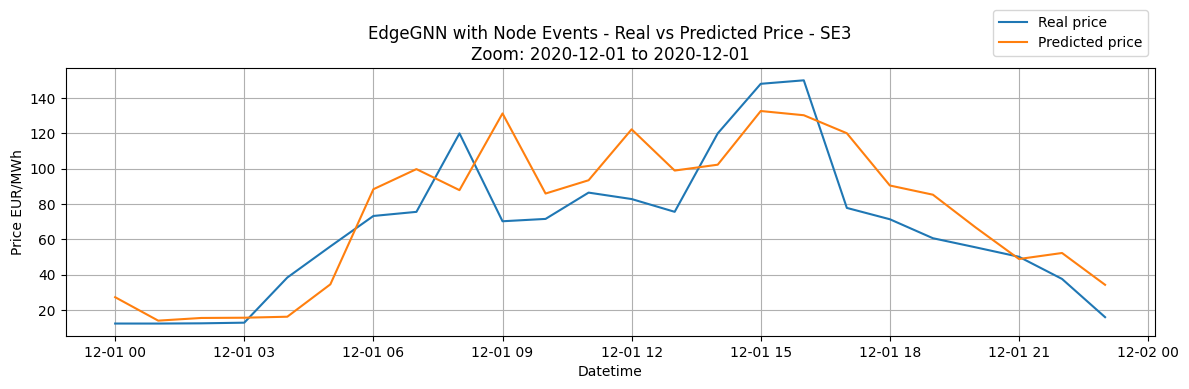

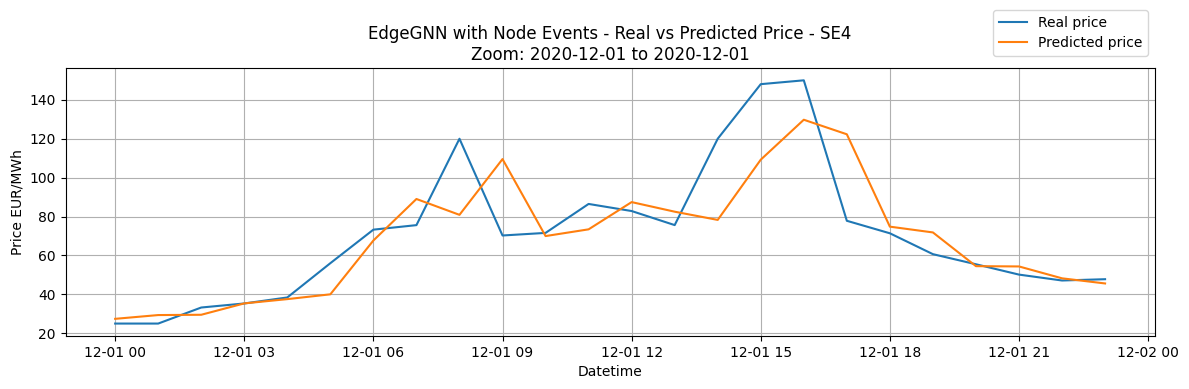

In [159]:
# ============================================================
# 28. PLOT EDGE GNN WITH NODE EVENTS - ALL ZONES WITH ZOOM
# ============================================================

zoom_start = pd.Timestamp("2020-12-01 00:00:00")
zoom_end = pd.Timestamp("2020-12-01 23:00:00")

for zone_to_plot in sorted(results_edge_events["zone_code"].unique()):
    plot_df = results_edge_events[
        (results_edge_events["zone_code"] == zone_to_plot) &
        (results_edge_events["datetime"] >= zoom_start) &
        (results_edge_events["datetime"] <= zoom_end)
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["datetime"], plot_df["y_true"], label="Real price")
    plt.plot(plot_df["datetime"], plot_df["y_pred"], label="Predicted price")

    plt.xlabel("Datetime")
    plt.ylabel("Price EUR/MWh")
    plt.title(
        f"EdgeGNN with Node Events - Real vs Predicted Price - {zone_to_plot}\n"
        f"Zoom: {zoom_start.date()} to {zoom_end.date()}"
    )

    plt.legend(loc="lower right", bbox_to_anchor=(1.0, 1.02))
    plt.grid(True)
    plt.tight_layout()
    plt.show()